# Worksheet 5 - Classification

- [Load dataset](#Load-dataset)
- [The Default data set](#Figure-4.1---Default-data-set)
- [4.3 Logistic Regression](#4.3-Logistic-Regression)
- [4.4 Linear Discriminant Analysis](#4.4-Linear-Discriminant-Analysis)
- [Lab: 4.6.3 Linear Discriminant Analysis](#4.6.3-Linear-Discriminant-Analysis)
- [Lab: 4.6.4 Quadratic Discriminant Analysis](#4.6.4-Quadratic-Discriminant-Analysis)
- [Lab: 4.6.5 K-Nearest Neighbors](#4.6.5-K-Nearest-Neighbors)
- [Lab: 4.6.6 An Application to Caravan Insurance Data](#4.6.6-An-Application-to-Caravan-Insurance-Data)

In [1]:
# %load ../standard_import.txt
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn.linear_model as skl_lm
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, precision_score
from sklearn import preprocessing
from sklearn import neighbors
# import the metrics class
from sklearn import metrics
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

import statsmodels.api as sm
import statsmodels.api as smf

%matplotlib inline
plt.style.use('seaborn-white')

### Load dataset

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/sukhjitsehra/datasets/master/CP322/Default.csv')
df.head(10)

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879
5,No,Yes,919.588530,7491.558572
6,No,No,825.513331,24905.226578
7,No,Yes,808.667504,17600.451344
8,No,No,1161.057854,37468.529288
9,No,No,0.000000,29275.268293


In [3]:
# Note: factorize() returns two objects: a label array and an array with the unique values.
# We are only interested in the first object. 
df['default2'] = df.default.factorize()[0]
df['student2'] = df.student.factorize()[0]
df.head(3)

,default,student,balance,income,default2,student2
0,No,No,729.526495,44361.625074,0,0
1,No,Yes,817.180407,12106.134700,0,1
2,No,No,1073.549164,31767.138947,0,0


###  Figure 4.1 - Default data set

C:\Users\ssehra\AppData\Local\Temp/ipykernel_11512/4168181577.py:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_ = df_no.append(df_yes)
c:\Users\ssehra\AppData\Local\Continuum\anaconda3\envs\r_40\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
c:\Users\ssehra\AppData\Local\Continuum\anaconda3\envs\r_40\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


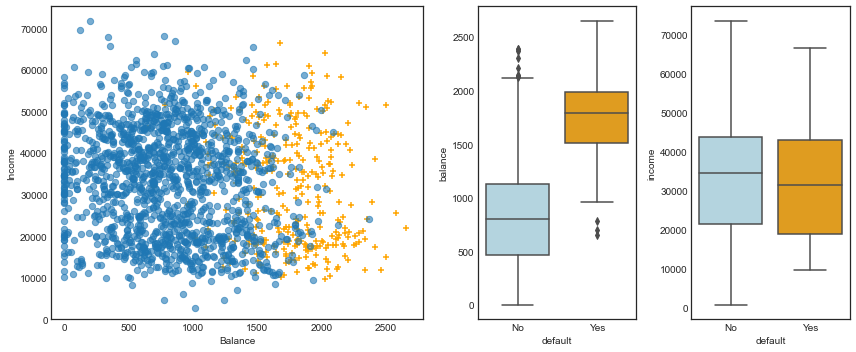

In [4]:
fig = plt.figure(figsize=(12,5))
gs = mpl.gridspec.GridSpec(1, 4)
ax1 = plt.subplot(gs[0,:-2])
ax2 = plt.subplot(gs[0,-2])
ax3 = plt.subplot(gs[0,-1])

# Take a fraction of the samples where target value (default) is 'no'
df_no = df[df.default2 == 0].sample(frac=0.15)

# Take all samples  where target value is 'yes'
df_yes = df[df.default2 == 1]
df_ = df_no.append(df_yes)

ax1.scatter(df_[df_.default == 'Yes'].balance, df_[df_.default == 'Yes'].income, s=40, c='orange', marker='+')
ax1.scatter(df_[df_.default == 'No'].balance, df_[df_.default == 'No'].income, s=40, marker='o', alpha=.6)

ax1.set_ylim(ymin=0)
ax1.set_ylabel('Income')
ax1.set_xlim(xmin=-100)
ax1.set_xlabel('Balance')
c_palette = {'No':'lightblue', 'Yes':'orange'}
sns.boxplot('default', 'balance', data=df, orient='v', ax=ax2, palette=c_palette)
sns.boxplot('default', 'income', data=df, orient='v', ax=ax3, palette=c_palette)
gs.tight_layout(plt.gcf())

## 4.3 Logistic Regression
### Figure 4.2

In [5]:
df.balance.max()

2654.32257628018

(array([[  13.,   18.,   31.,   37.,   43.,   62.,  110.,  148.,  332.,
         9206.],
        [9206.,  332.,  148.,  110.,   62.,   43.,   37.,   31.,   18.,
           13.]]),
 array([2.36688981e-05, 1.00018935e-01, 2.00014201e-01, 3.00009468e-01,
        4.00004734e-01, 5.00000000e-01, 5.99995266e-01, 6.99990532e-01,
        7.99985799e-01, 8.99981065e-01, 9.99976331e-01]),
 <a list of 2 BarContainer objects>)

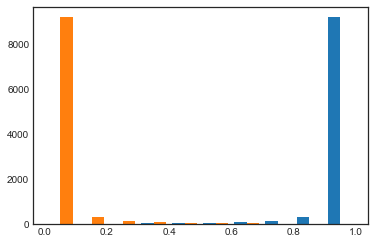

In [6]:
X_train = df.balance.values.reshape(-1,1) 
y = df.default2

# Create array of test data. Calculate the classification probability
# and predicted classification.
X_test = np.arange(df.balance.min(), df.balance.max()).reshape(-1,1)

clf = skl_lm.LogisticRegression(solver='newton-cg')
clf.fit(X_train,y)

prob_train = clf.predict_proba(X_train)
plt.hist(prob_train)


(array([[ 318.,  147.,   98.,   81.,   74.,   73.,   81.,   98.,  147.,
         1538.],
        [1538.,  147.,   98.,   81.,   73.,   74.,   81.,   98.,  147.,
          318.]]),
 array([2.36688981e-05, 1.00018935e-01, 2.00014201e-01, 3.00009468e-01,
        4.00004734e-01, 5.00000000e-01, 5.99995266e-01, 6.99990532e-01,
        7.99985799e-01, 8.99981065e-01, 9.99976331e-01]),
 <a list of 2 BarContainer objects>)

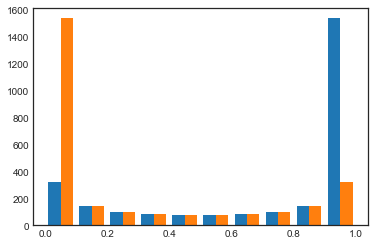

In [7]:

prob_test = clf.predict_proba(X_test)
plt.hist(prob_test)

(array([9858.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
         142.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

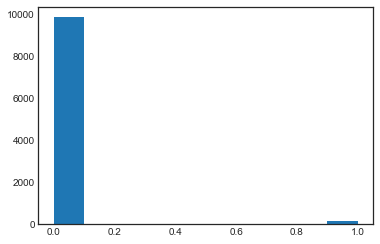

In [8]:
pred_train = clf.predict(X_train)
plt.hist(pred_train)


(array([1937.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
         718.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

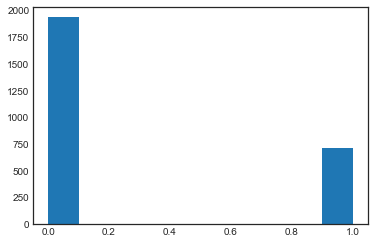

In [9]:

pred_test = clf.predict(X_test)
plt.hist(pred_test)

c:\Users\ssehra\AppData\Local\Continuum\anaconda3\envs\r_40\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


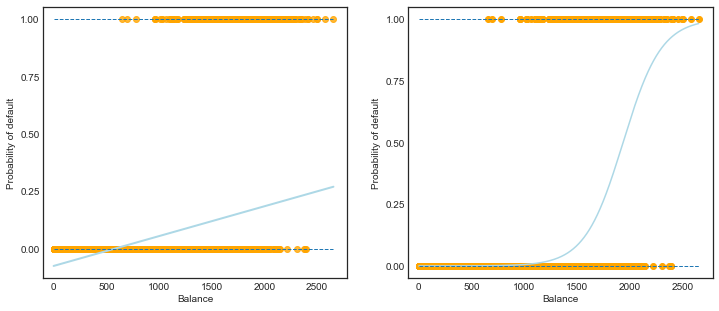

In [10]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
# Left plot
sns.regplot(df.balance, df.default2, order=1, ci=None,
            scatter_kws={'color':'orange'},
            line_kws={'color':'lightblue', 'lw':2}, ax=ax1)
# Right plot
ax2.scatter(X_train, y, color='orange')
ax2.plot(X_test, prob_test[:,1], color='lightblue')

for ax in fig.axes:
    ax.hlines(1, xmin=ax.xaxis.get_data_interval()[0],
              xmax=ax.xaxis.get_data_interval()[1], linestyles='dashed', lw=1)
    ax.hlines(0, xmin=ax.xaxis.get_data_interval()[0],
              xmax=ax.xaxis.get_data_interval()[1], linestyles='dashed', lw=1)
    ax.set_ylabel('Probability of default')
    ax.set_xlabel('Balance')
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.])
    ax.set_xlim(xmin=-100)

### Table 4.1

#####  scikit-learn

In [11]:
# Using newton-cg solver, the coefficients are equal/closest to the ones in the book. 
# I do not know the details on the differences between the solvers.
clf = skl_lm.LogisticRegression(solver='newton-cg')
X_train = df.balance.values.reshape(-1,1)
clf.fit(X_train,y)
print(clf)
print('classes: ',clf.classes_)
print('coefficients: ',clf.coef_)
print('intercept :', clf.intercept_)

LogisticRegression(solver='newton-cg')
classes:  [0 1]
coefficients:  [[0.00549891]]
intercept : [-10.65132502]


##### statsmodels

In [12]:
X_train = sm.add_constant(df.balance)
y = y.ravel()
est = smf.Logit(y, X_train).fit()
est.summary2().tables[1]

Optimization terminated successfully.
         Current function value: 0.079823
         Iterations 10


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
const,-10.651331,0.361169,-29.491287,3.723665e-191,-11.359208,-9.943453
balance,0.005499,0.000220,24.952404,2.010855e-137,0.005067,0.005931


###  Table 4.2

In [13]:
X_train = sm.add_constant(df.student2)
y = df.default2

est = smf.Logit(y, X_train).fit()
est.summary2().tables[1]

Optimization terminated successfully.
         Current function value: 0.145434
         Iterations 7


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
const,-3.504128,0.070713,-49.554094,0.000000,-3.642723,-3.365532
student2,0.404887,0.115019,3.520177,0.000431,0.179454,0.630320


###  Table 4.3 - Multiple Logistic Regression

In [14]:
X_train = sm.add_constant(df[['balance', 'income', 'student2']])
est = smf.Logit(y, X_train).fit()
est.summary2().tables[1]

Optimization terminated successfully.
         Current function value: 0.078577
         Iterations 10


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
const,-10.869045,0.492273,-22.079320,4.995499e-108,-11.833882,-9.904209
balance,0.005737,0.000232,24.736506,4.331521e-135,0.005282,0.006191
income,0.000003,0.000008,0.369808,7.115254e-01,-0.000013,0.000019
student2,-0.646776,0.236257,-2.737595,6.189022e-03,-1.109831,-0.183721


### Figure 4.3 - Confounding

In [74]:
# balance and default vectors for students
X_train = df[df.student == 'Yes'].balance.values.reshape(df[df.student == 'Yes'].balance.size,1) 
y = df[df.student == 'Yes'].default2

# balance and default vectors for non-students
X_train2 = df[df.student == 'No'].balance.values.reshape(df[df.student == 'No'].balance.size,1) 
y2 = df[df.student == 'No'].default2

# Vector with balance values for plotting
X_test = np.arange(df.balance.min(), df.balance.max()).reshape(-1,1)
X_test
clf = skl_lm.LogisticRegression(solver='newton-cg')
clf2 = skl_lm.LogisticRegression(solver='newton-cg')

clf.fit(X_train,y)
clf2.fit(X_train2,y2)

prob = clf.predict_proba(X_test)
print(prob)

prob2 = clf2.predict_proba(X_test)
print(prob2)

[[9.99986676e-01 1.33244901e-05]
 [9.99986601e-01 1.33993045e-05]
 [9.99986525e-01 1.34745390e-05]
 ...
 [2.60048716e-02 9.73995128e-01]
 [2.58634279e-02 9.74136572e-01]
 [2.57227333e-02 9.74277267e-01]]
[[9.99981069e-01 1.89311864e-05]
 [9.99980958e-01 1.90416625e-05]
 [9.99980847e-01 1.91527833e-05]
 ...
 [1.03863920e-02 9.89613608e-01]
 [1.03267533e-02 9.89673247e-01]
 [1.02674535e-02 9.89732546e-01]]


c:\Users\ssehra\AppData\Local\Continuum\anaconda3\envs\r_40\lib\site-packages\scipy\optimize\_linesearch.py:305: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
c:\Users\ssehra\AppData\Local\Continuum\anaconda3\envs\r_40\lib\site-packages\sklearn\utils\optimize.py:203: UserWarning: Line Search failed
  warnings.warn("Line Search failed")


In [75]:
df.groupby(['student','default']).size().unstack('default')

default,No,Yes
student,,
No,6850,206
Yes,2817,127


c:\Users\ssehra\AppData\Local\Continuum\anaconda3\envs\r_40\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


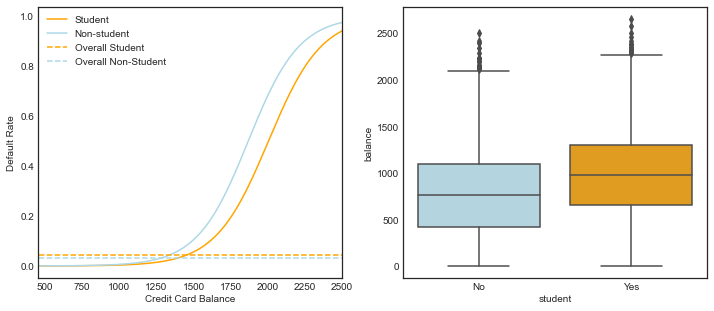

In [76]:
# creating plot
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

# Left plot
ax1.plot(X_test, pd.DataFrame(prob)[1], color='orange', label='Student')
ax1.plot(X_test, pd.DataFrame(prob2)[1], color='lightblue', label='Non-student')
ax1.hlines(127/2817, colors='orange', label='Overall Student',
           xmin=ax1.xaxis.get_data_interval()[0],
           xmax=ax1.xaxis.get_data_interval()[1], linestyles='dashed')
ax1.hlines(206/6850, colors='lightblue', label='Overall Non-Student',
           xmin=ax1.xaxis.get_data_interval()[0],
           xmax=ax1.xaxis.get_data_interval()[1], linestyles='dashed')
ax1.set_ylabel('Default Rate')
ax1.set_xlabel('Credit Card Balance')
ax1.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.])
ax1.set_xlim(450,2500)
ax1.legend(loc=2)

# Right plot
sns.boxplot('student', 'balance', data=df, orient='v', ax=ax2,  palette=c_palette);

## Logistic Model

In [15]:
X = df[['balance', 'income', 'student2']]
y=df.default2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

fit_model = skl_lm.LogisticRegression(random_state=42)

# fit the model with data
fit_model.fit(X_train, y_train)

y_pred = fit_model.predict(X_test)

cnf_matrix_logit = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix_logit

print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.97      1.00      0.98       958
         Yes       0.67      0.19      0.30        42

    accuracy                           0.96      1000
   macro avg       0.82      0.59      0.64      1000
weighted avg       0.95      0.96      0.95      1000



Text(0.5, 257.44, 'Predicted label')

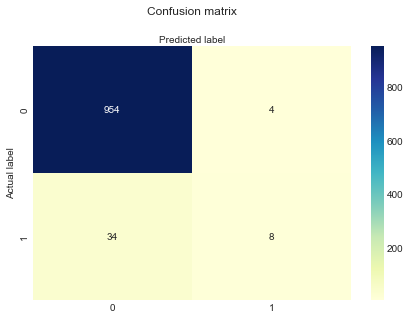

In [16]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_logit), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

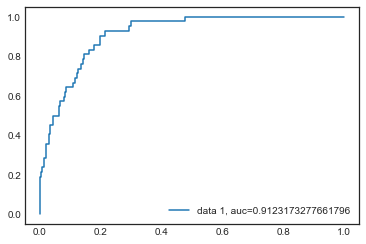

In [17]:
y_pred_proba = fit_model.predict_proba(X_test)[::,1]
fpr_logit, tpr_logit, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr_logit,tpr_logit,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

## 4.4 Linear Discriminant Analysis
### Table 4.4 


In [18]:

fit_lda = LinearDiscriminantAnalysis(solver='svd')
y_pred_lda = fit_lda.fit(X_train, y_train).predict(X_test)

cnf_matrix_lda =  metrics.confusion_matrix(y_test, y_pred)
cnf_matrix_lda

# df_ = pd.DataFrame({'True default status': y_test,
#                     'Predicted default status': y_pred})
# df_.replace(to_replace={0:'No', 1:'Yes'}, inplace=True)

# df_.groupby(['Predicted default status','True default status']).size().unstack('True default status')

array([[954,   4],
       [ 34,   8]], dtype=int64)

In [19]:
print(
    _report(y_test, y_pred_lda, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.96      1.00      0.98       958
         Yes       0.70      0.17      0.27        42

    accuracy                           0.96      1000
   macro avg       0.83      0.58      0.62      1000
weighted avg       0.95      0.96      0.95      1000



Text(0.5, 257.44, 'Predicted label')

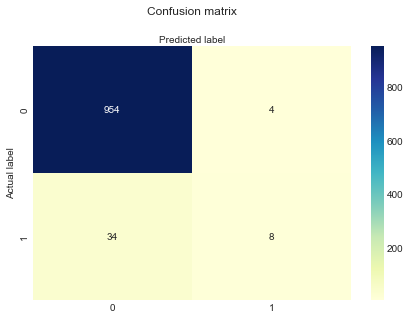

In [20]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_lda), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

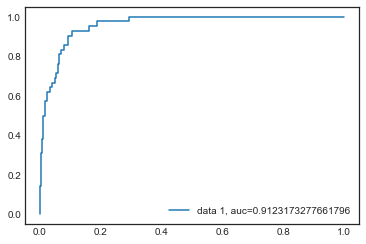

In [21]:
y_pred_lda_proba = fit_lda.predict_proba(X_test)[::,1]
fpr_lda, tpr_lda, _ = metrics.roc_curve(y_test,  y_pred_lda_proba)
auc_lda = metrics.roc_auc_score(y_test, y_pred_lda_proba)
plt.plot(fpr_lda,tpr_lda,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

### Table 4.5
Instead of using the probability of 50% as decision boundary, we say that a probability of default of 20% is to be classified as 'Yes'.

In [22]:
decision_prob = 0.2
y_prob_lda = fit_lda.fit(X, y).predict_proba(X_test)

df_ = pd.DataFrame({'True default status': y_test,
                    'Predicted default status': y_prob_lda[:,1] > decision_prob})
df_.replace(to_replace={0:'No', 1:'Yes', 'True':'Yes', 'False':'No'}, inplace=True)

df_.groupby(['Predicted default status','True default status']).size().unstack('True default status')

True default status,No,Yes
Predicted default status,,
False,938,18
True,20,24


# QDA

              precision    recall  f1-score   support

          No       0.97      1.00      0.98       958
         Yes       0.75      0.21      0.33        42

    accuracy                           0.96      1000
   macro avg       0.86      0.61      0.66      1000
weighted avg       0.96      0.96      0.95      1000



Text(0.5, 257.44, 'Predicted label')

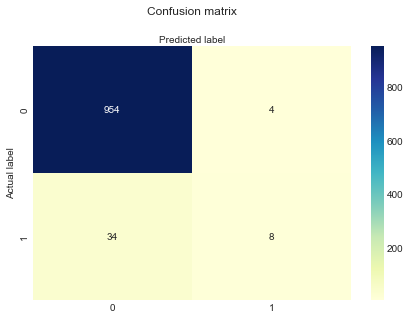

In [23]:
fit_qda = QuadraticDiscriminantAnalysis()
y_pred_qda = fit_qda.fit(X_train, y_train).predict(X_test)

cnf_matrix_qda =  metrics.confusion_matrix(y_test, y_pred)
cnf_matrix_qda

print(classification_report(y_test, y_pred_qda, target_names=['No', 'Yes']))

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_qda), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')


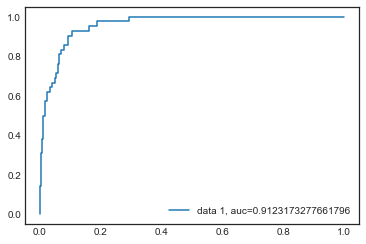

In [24]:

y_pred_qda_proba = fit_qda.predict_proba(X_test)[::,1]
fpr_qda, tpr_qda, _ = metrics.roc_curve(y_test,  y_pred_qda_proba)
auc_qda = metrics.roc_auc_score(y_test, y_pred_qda_proba)
plt.plot(fpr_lda,tpr_lda,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

# Knn

[[953   5]
 [ 36   6]]
              precision    recall  f1-score   support

           0      0.964     0.995     0.979       958
           1      0.545     0.143     0.226        42

    accuracy                          0.959      1000
   macro avg      0.755     0.569     0.603      1000
weighted avg      0.946     0.959     0.947      1000



Text(0.5, 257.44, 'Predicted label')

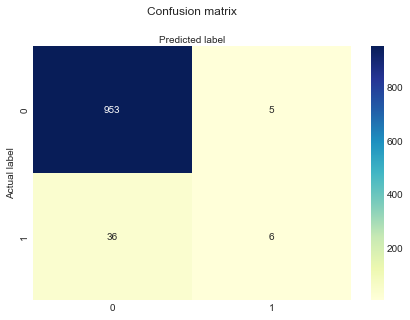

In [36]:
fit_knn = neighbors.KNeighborsClassifier(n_neighbors=5)
y_pred_knn = fit_knn.fit(X_train, y_train).predict(X_test)
cnf_matrix_knn = metrics.confusion_matrix(y_test, y_pred_knn)
print(cnf_matrix_knn)
print(classification_report(y_test, y_pred_knn, digits=3))

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_knn), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

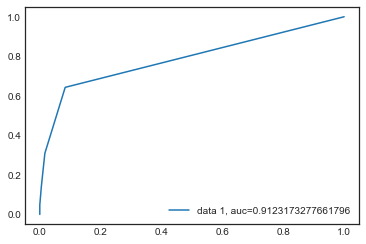

In [37]:
y_pred_knn_proba = fit_knn.predict_proba(X_test)[::,1]
fpr_knn, tpr_knn, _ = metrics.roc_curve(y_test,  y_pred_knn_proba)
auc_knn = metrics.roc_auc_score(y_test, y_pred_knn_proba)
plt.plot(fpr_knn,tpr_knn,label="data 1, auc="+str(auc))

plt.legend(loc=4)
plt.show()

## Naive Bayes

[[951   7]
 [ 34   8]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       958
           1       0.53      0.19      0.28        42

    accuracy                           0.96      1000
   macro avg       0.75      0.59      0.63      1000
weighted avg       0.95      0.96      0.95      1000



Text(0.5, 257.44, 'Predicted label')

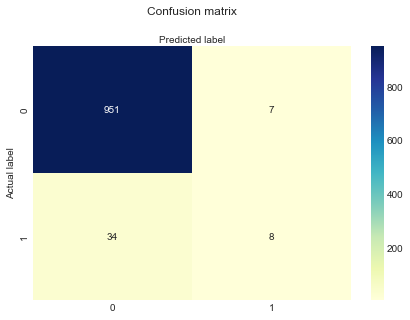

In [27]:
fit_gnb = GaussianNB()
y_pred_gnb = fit_gnb.fit(X_train, y_train).predict(X_test)
cnf_matrix_gnb = metrics.confusion_matrix(y_test, y_pred_gnb)
print(cnf_matrix_gnb)
print(classification_report(y_test, y_pred_gnb))

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_gnb), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

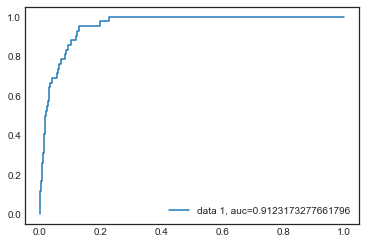

In [28]:
y_pred_gnb_proba = fit_gnb.predict_proba(X_test)[::,1]
fpr_gnb, tpr_gnb, _ = metrics.roc_curve(y_test,  y_pred_gnb_proba)
auc_gnb = metrics.roc_auc_score(y_test, y_pred_gnb_proba)
plt.plot(fpr_gnb, tpr_gnb,label="data 1, auc="+str(auc))

plt.legend(loc=4)
plt.show()

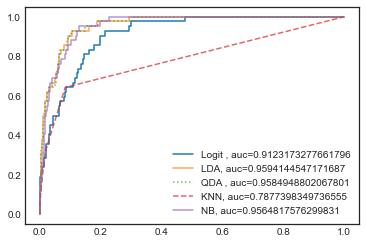

In [38]:
plt.plot(fpr_logit,tpr_logit, label = "Logit , auc="+str(auc))
plt.plot(fpr_lda,tpr_lda, label = "LDA, auc="+str(auc_lda),  alpha=0.7, linestyle='-')
plt.plot(fpr_qda, tpr_qda, label = "QDA , auc="+str(auc_qda),  alpha=0.7, linestyle=':')
plt.plot(fpr_knn,tpr_knn, label = "KNN, auc="+str(auc_knn),  alpha=0.7, linestyle='--')
plt.plot(fpr_gnb, tpr_gnb, label = "NB, auc="+str(auc_gnb),  alpha=0.7)
plt.legend(loc=4)
plt.show()

# Three plots are merging so not clearly visible.

### 4.6.3 Linear Discriminant Analysis

In [92]:
df = pd.read_csv('https://raw.githubusercontent.com/sukhjitsehra/datasets/master/CP322/Smarket.csv', index_col=0, parse_dates=True)
df.head(20)

,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
Year,,,,,,,,
2001-01-01,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
2001-01-01,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2001-01-01,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
2001-01-01,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
2001-01-01,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up
2001-01-01,0.213,0.614,-0.623,1.032,0.959,1.3491,1.392,Up
2001-01-01,1.392,0.213,0.614,-0.623,1.032,1.4450,-0.403,Down
2001-01-01,-0.403,1.392,0.213,0.614,-0.623,1.4078,0.027,Up
2001-01-01,0.027,-0.403,1.392,0.213,0.614,1.1640,1.303,Up


In [93]:
X_train = df[:'2004'][['Lag1','Lag2']]
y_train = df[:'2004']['Direction']

X_test = df['2005':][['Lag1','Lag2']]
y_test = df['2005':]['Direction']

lda = LinearDiscriminantAnalysis()
pred = lda.fit(X_train, y_train).predict(X_test)

In [94]:
lda.priors_

array([0.49198397, 0.50801603])

In [95]:
lda.means_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [96]:
# These do not seem to correspond to the values from the R output in the book?
lda.coef_

array([[-0.05544078, -0.0443452 ]])

In [97]:
confusion_matrix(y_test, pred).T

array([[ 35,  35],
       [ 76, 106]], dtype=int64)

In [98]:
print(classification_report(y_test, pred, digits=3))

              precision    recall  f1-score   support

        Down      0.500     0.315     0.387       111
          Up      0.582     0.752     0.656       141

    accuracy                          0.560       252
   macro avg      0.541     0.534     0.522       252
weighted avg      0.546     0.560     0.538       252



In [99]:
pred_p = lda.predict_proba(X_test)

In [100]:
np.unique(pred_p[:,1]>0.5, return_counts=True)

(array([False,  True]), array([ 70, 182], dtype=int64))

In [101]:
np.unique(pred_p[:,1]>0.9, return_counts=True)

(array([False]), array([252], dtype=int64))

### 4.6.4 Quadratic Discriminant Analysis

In [102]:
qda = QuadraticDiscriminantAnalysis()
pred = qda.fit(X_train, y_train).predict(X_test)

In [103]:
qda.priors_

array([0.49198397, 0.50801603])

In [104]:
qda.means_

array([[ 0.04279022,  0.03389409],
       [-0.03954635, -0.03132544]])

In [105]:
confusion_matrix(y_test, pred).T

array([[ 30,  20],
       [ 81, 121]], dtype=int64)

In [106]:
print(classification_report(y_test, pred, digits=3))

              precision    recall  f1-score   support

        Down      0.600     0.270     0.373       111
          Up      0.599     0.858     0.706       141

    accuracy                          0.599       252
   macro avg      0.600     0.564     0.539       252
weighted avg      0.599     0.599     0.559       252



### 4.6.5 K-Nearest Neighbors

In [107]:
knn = neighbors.KNeighborsClassifier(n_neighbors=1)
pred = knn.fit(X_train, y_train).predict(X_test)
print(confusion_matrix(y_test, pred).T)
print(classification_report(y_test, pred, digits=3))

[[43 58]
 [68 83]]
              precision    recall  f1-score   support

        Down      0.426     0.387     0.406       111
          Up      0.550     0.589     0.568       141

    accuracy                          0.500       252
   macro avg      0.488     0.488     0.487       252
weighted avg      0.495     0.500     0.497       252



In [108]:
knn = neighbors.KNeighborsClassifier(n_neighbors=3)
pred = knn.fit(X_train, y_train).predict(X_test)
print(confusion_matrix(y_test, pred).T)
print(classification_report(y_test, pred, digits=3))

[[48 55]
 [63 86]]
              precision    recall  f1-score   support

        Down      0.466     0.432     0.449       111
          Up      0.577     0.610     0.593       141

    accuracy                          0.532       252
   macro avg      0.522     0.521     0.521       252
weighted avg      0.528     0.532     0.529       252



### 4.6.6 An Application to Caravan Insurance Data

#### K-Nearest Neighbors

In [109]:
df = pd.read_csv('https://raw.githubusercontent.com/sukhjitsehra/datasets/master/CP322/Caravan.csv')
y = df.Purchase
X = df.drop('Purchase', axis=1).astype('float64')
X_scaled = preprocessing.scale(X)

X_train = X_scaled[1000:,:]
y_train = y[1000:]
X_test = X_scaled[:1000,:]
y_test = y[:1000]

def KNN(n_neighbors=1):
    clf = neighbors.KNeighborsClassifier(n_neighbors)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    score = clf.score(X_test, y_test)
    return(pred, score, clf.classes_)

def plot_confusion_matrix(cm, classes, n_neighbors, title='Confusion matrix (Normalized)',
                          cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Normalized confusion matrix: KNN-{}'.format(n_neighbors))
    plt.colorbar()
    plt.xticks(np.arange(2), classes)
    plt.yticks(np.arange(2), classes)
    plt.tight_layout()
    plt.xlabel('True label',rotation='horizontal', ha='right')
    plt.ylabel('Predicted label')
    plt.show()

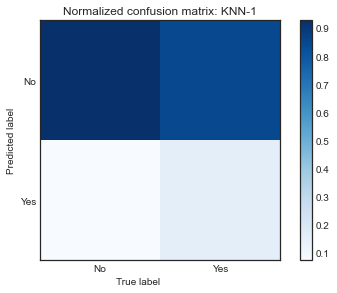

True        No  Yes
Predicted          
No         873   50
Yes         68    9
     Precision
No    0.945829
Yes   0.116883


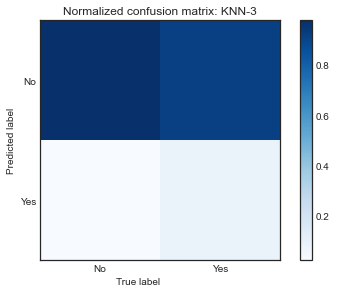

True        No  Yes
Predicted          
No         921   54
Yes         20    5
     Precision
No    0.944615
Yes   0.200000


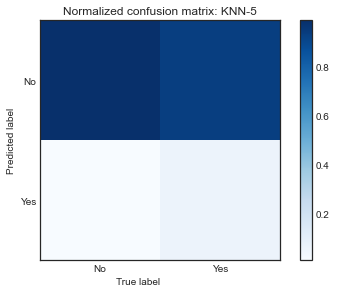

True        No  Yes
Predicted          
No         930   55
Yes         11    4
     Precision
No    0.944162
Yes   0.266667


In [110]:
for i in [1, 3, 5]:
    pred, score, classes = KNN(n_neighbors=i)
    cm = confusion_matrix(y_test, pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plot_confusion_matrix(cm_normalized.T, classes, n_neighbors=i)
    cm_df = pd.DataFrame(cm.T, index=classes, columns=classes)
    cm_df.index.name = 'Predicted'
    cm_df.columns.name = 'True'
    print(cm_df)    
    print(pd.DataFrame(precision_score(y_test, pred, average=None),
                       index=classes, columns=['Precision']))        

####  Logistic Regression

In [111]:
regr = skl_lm.LogisticRegression()
regr.fit(X_train, y_train)

c:\Users\ssehra\AppData\Local\Continuum\anaconda3\envs\r_40\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [112]:
pred = regr.predict(X_test)
cm_df = pd.DataFrame(confusion_matrix(y_test, pred).T, index=regr.classes_,
                     columns=regr.classes_)
cm_df.index.name = 'Predicted'
cm_df.columns.name = 'True'
print(cm_df)
print(classification_report(y_test, pred))

True        No  Yes
Predicted          
No         934   59
Yes          7    0
              precision    recall  f1-score   support

          No       0.94      0.99      0.97       941
         Yes       0.00      0.00      0.00        59

    accuracy                           0.93      1000
   macro avg       0.47      0.50      0.48      1000
weighted avg       0.89      0.93      0.91      1000



In [113]:
pred_p = regr.predict_proba(X_test)
cm_df = pd.DataFrame({'True': y_test, 'Pred': pred_p[:,1] > .25})
cm_df.Pred.replace(to_replace={True:'Yes', False:'No'}, inplace=True)
print(cm_df.groupby(['True', 'Pred']).size().unstack('True').T)
print(classification_report(y_test, cm_df.Pred))

Pred   No  Yes
True          
No    917   24
Yes    48   11
              precision    recall  f1-score   support

          No       0.95      0.97      0.96       941
         Yes       0.31      0.19      0.23        59

    accuracy                           0.93      1000
   macro avg       0.63      0.58      0.60      1000
weighted avg       0.91      0.93      0.92      1000

